Average daily return: 0.0009023955558272928
Volatility (risk): 0.035442460629887575
Sharpe Ratio: 0.02263938624934682


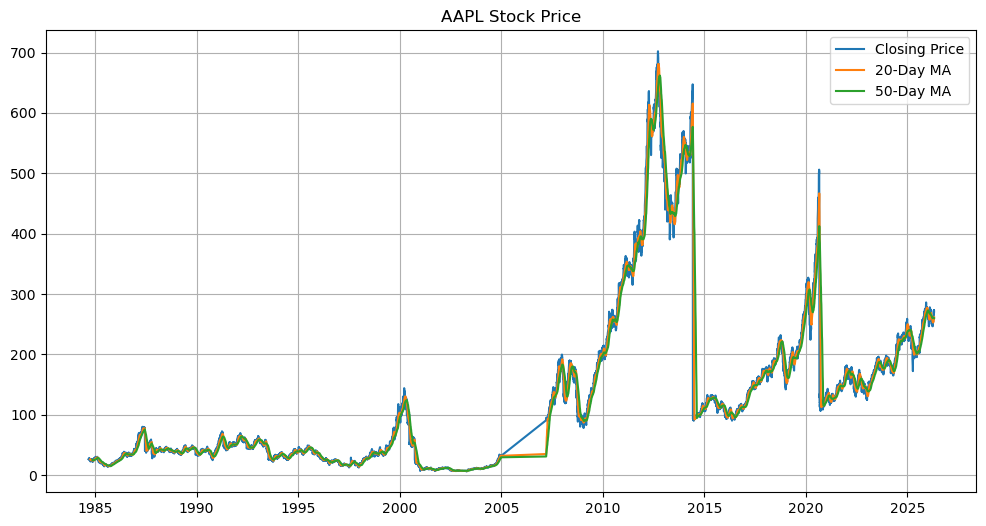

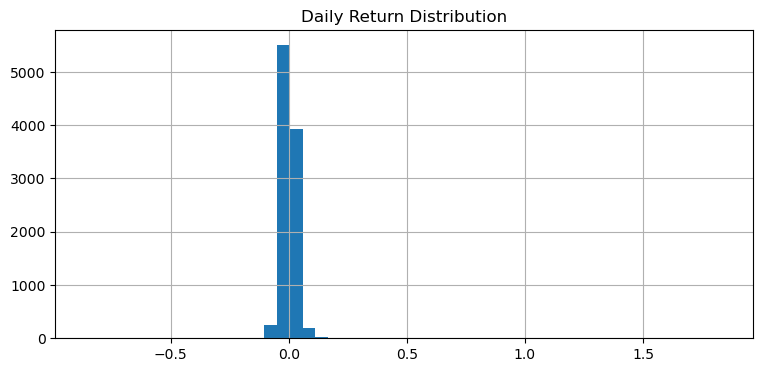

interactive(children=(Dropdown(description='stock', options=('AAPL', 'TSLA', 'MSFT', 'GOOGL', 'AMZN'), value='…

<function __main__.analyze(stock)>

In [11]:
# %% [markdown]
# # Stock Analysis Tool
# ## Mingyang Liu | 2471001
# Track 4 - Interactive Data Analysis

# %% [markdown]
# # 1. Project Overview

# ## Analytical Problem
# Many beginner investors do not have simple tools to evaluate stock performance and risk.
# This project aims to analyse stock prices, returns, and volatility using Python.

# ## Objective
# - Analyse stock price trends
# - Measure return and risk
# - Provide simple interactive analysis

# %% [markdown]
# ## Data Source
# Stock data is collected using Akshare. I chose this source because Yahoo Finance had access issues during testing..

# %%
# Install required libraries
!pip install akshare ipywidgets

# %%
# Import libraries
import akshare as ak
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display

# %% [markdown]
# # 2. Get Stock Data
def get_stock_data(stock):
    data = ak.stock_us_daily(symbol=stock)
    
    data['date'] = pd.to_datetime(data['date'])
    data.set_index('date', inplace=True)
    
    data = data.sort_index()
    
    # Rename columns to match yfinance format
    data.rename(columns={
        'open': 'Open',
        'high': 'High',
        'low': 'Low',
        'close': 'Close',
        'volume': 'Volume'
    }, inplace=True)
    
    return data

# %%
# Load data
stock = "AAPL"
data = get_stock_data(stock)

# Show first rows
data.head()

# %% [markdown]
# # 3. Clean and Prepare Data
data = data.dropna()
data["Return"] = data["Close"].pct_change()
data["MA20"] = data["Close"].rolling(window=20).mean()
data["MA50"] = data["Close"].rolling(window=50).mean()
data.head()

# %% [markdown]
# # 4. Basic Statistics (Return and Risk)
mean_return = data["Return"].mean()
volatility = data["Return"].std()
risk_free_rate = 0.0001
sharpe_ratio = (mean_return - risk_free_rate) / volatility

print("Average daily return:", mean_return)
print("Volatility (risk):", volatility)
print("Sharpe Ratio:", sharpe_ratio)

# %% [markdown]
# # 5. Visualize Stock Price and Trends
plt.figure(figsize=(12,6))
plt.plot(data["Close"], label="Closing Price")
plt.plot(data["MA20"], label="20-Day MA")
plt.plot(data["MA50"], label="50-Day MA")

plt.title(f"{stock} Stock Price")
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(9,4))
plt.hist(data["Return"].dropna(), bins=50)
plt.title("Daily Return Distribution")
plt.grid(True)
plt.show()

# %% [markdown]
# # 6. Interactive Stock Analyzer
def analyze(stock):
    data = get_stock_data(stock)
    data = data.dropna()
    
    data["Return"] = data["Close"].pct_change()
    data["MA20"] = data["Close"].rolling(20).mean()
    data["MA50"] = data["Close"].rolling(50).mean()
    
    mean_ret = data["Return"].mean()
    vol = data["Return"].std()
    
    risk_free_rate = 0.0001
    sharpe = (mean_ret - risk_free_rate) / vol
    
    print(f"Stock: {stock}")
    print(f"Mean return: {mean_ret}")
    print(f"Volatility: {vol}")
    print(f"Sharpe Ratio: {sharpe}")
    
    plt.figure(figsize=(12,6))
    plt.plot(data["Close"], label="Close Price")
    plt.plot(data["MA20"], label="MA20")
    plt.plot(data["MA50"], label="MA50")
    plt.title(stock + " Price Chart")
    plt.legend()
    plt.grid(True)
    plt.show()

# %%
widgets.interact(
    analyze,
    stock=["AAPL", "TSLA", "MSFT", "GOOGL", "AMZN"]
)